# RDF N-Triples Analysis Notebook using rdflib


In [37]:
name = "currency"

# =========================

# 1. Setup

# =========================


In [38]:
from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF, RDFS, SKOS, XSD
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

## Helper Functions


In [39]:
def parse_file_safe(graph, path):
    encodings = ["utf-8", "latin-1", "cp1252"]

    for enc in encodings:
        try:
            with open(path, "r", encoding=enc) as f:
                graph.parse(f, format="nt")
            print(f"Loaded {path} with {enc}")
            return
        except UnicodeDecodeError:
            continue

    print(f"Failed to parse {path}")

# =========================

# 2. Load N-Triples Files

# =========================


In [40]:
import os

data_dir = "data"
g = Graph()


for file in os.listdir(data_dir):
    if name in file and file.endswith(".ntriples"):
        path = os.path.join(data_dir, file)
        print(f"Loading {path}")
        parse_file_safe(g, path)

print(f"Total triples loaded: {len(g)}")

Loading data\OpenPermID-bulk-currency.ntriples
Loaded data\OpenPermID-bulk-currency.ntriples with utf-8
Total triples loaded: 120


# =========================

# 3. Inspect Basic Structure

# =========================


In [41]:
# Print first 10 triples
for i, (s, p, o) in enumerate(g):
    if i >= 10:
        break
    print(s, p, o)

https://permid.org/1-USD https://permid.org/ontology/financial/currencySymbol $
https://permid.org/1-SEK https://permid.org/ontology/financial/isoCode SEK
https://permid.org/1-CHF https://permid.org/ontology/financial/isoCode CHF
https://permid.org/1-DKK https://permid.org/ontology/financial/isoCode DKK
https://permid.org/1-NZD https://permid.org/ontology/financial/currencySymbol NZ$
https://permid.org/1-CHF https://permid.org/ontology/financial/isActive true
https://permid.org/1-BRL http://www.w3.org/2000/01/rdf-schema#label Brazilian Real
https://permid.org/1-SGD https://permid.org/ontology/financial/isoCode SGD
https://permid.org/1-AUD https://permid.org/ontology/financial/issuingCountry Australia
https://permid.org/1-DKK https://permid.org/ontology/financial/currencySymbol kr


# =========================

# 4. Explore Unique Elements

# =========================


In [42]:
subjects = set()
predicates = set()
uri_predicates = set()
literal_predicates = set()
objects = set()
both = set()
count = 0
for s, p, o in g:
    subjects.add(s)
    predicates.add(p)
    objects.add(o)
    both.add(s)
    both.add(o)
    if isinstance(o, Literal):
        literal_predicates.add(p)
    else:
        uri_predicates.add(p)
    count += 1


print("Total Size:", count)
print("Unique subjects:", len(subjects))
print("Unique predicates:", len(predicates))
print("Unique objects:", len(objects))
print("Unique Both:", len(both))

Total Size: 120
Unique subjects: 20
Unique predicates: 6
Unique objects: 78
Unique Both: 98


In [43]:
print(uri_predicates)


{rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type')}


In [44]:
print(literal_predicates)

{rdflib.term.URIRef('https://permid.org/ontology/financial/isoCode'), rdflib.term.URIRef('https://permid.org/ontology/financial/currencySymbol'), rdflib.term.URIRef('https://permid.org/ontology/financial/issuingCountry'), rdflib.term.URIRef('https://permid.org/ontology/financial/isActive'), rdflib.term.URIRef('http://www.w3.org/2000/01/rdf-schema#label')}


Conclusion: Majority of subjects are not objects


# =========================

# 5. Convert to DataFrame

# =========================


In [45]:
data = [(str(s), str(p), str(o)) for s, p, o in g]
df = pd.DataFrame(data, columns=["subject", "predicate", "object"])

df.head()

# Predicate frequency
predicate_counts = df["predicate"].value_counts()
predicate_counts.head(10)

predicate
https://permid.org/ontology/financial/currencySymbol    20
https://permid.org/ontology/financial/isoCode           20
https://permid.org/ontology/financial/isActive          20
http://www.w3.org/2000/01/rdf-schema#label              20
https://permid.org/ontology/financial/issuingCountry    20
http://www.w3.org/1999/02/22-rdf-syntax-ns#type         20
Name: count, dtype: int64

# =========================

# 6. Namespace Handling

# =========================


In [46]:
EX = Namespace("http://permid.org/")

# Bind namespace (useful for serialization)
g.bind("ex", EX)

# =========================

# 7. Filtering Triples

# =========================


In [47]:
# Example: get all labels
labels = []
for s, p, o in g.triples((None, RDFS.label, None)):
    labels.append((s, o))

print("Sample labels:")
print(labels[:10])

Sample labels:
[(rdflib.term.URIRef('https://permid.org/1-USD'), rdflib.term.Literal('US Dollar', lang='en')), (rdflib.term.URIRef('https://permid.org/1-EUR'), rdflib.term.Literal('Euro', lang='en')), (rdflib.term.URIRef('https://permid.org/1-GBP'), rdflib.term.Literal('British Pound Sterling', lang='en')), (rdflib.term.URIRef('https://permid.org/1-JPY'), rdflib.term.Literal('Japanese Yen', lang='en')), (rdflib.term.URIRef('https://permid.org/1-CHF'), rdflib.term.Literal('Swiss Franc', lang='en')), (rdflib.term.URIRef('https://permid.org/1-AUD'), rdflib.term.Literal('Australian Dollar', lang='en')), (rdflib.term.URIRef('https://permid.org/1-CAD'), rdflib.term.Literal('Canadian Dollar', lang='en')), (rdflib.term.URIRef('https://permid.org/1-CNY'), rdflib.term.Literal('Chinese Yuan Renminbi', lang='en')), (rdflib.term.URIRef('https://permid.org/1-HKD'), rdflib.term.Literal('Hong Kong Dollar', lang='en')), (rdflib.term.URIRef('https://permid.org/1-SGD'), rdflib.term.Literal('Singapore Dol

# =========================

# 8. SPARQL Queries

# =========================


In [48]:
query = """
SELECT ?s ?label
WHERE {
    ?s <http://www.w3.org/2000/01/rdf-schema#label> ?label .
}
LIMIT 10
"""

for row in g.query(query):
    print(row)

# More complex query: hierarchical relations
query_hierarchy = """
SELECT ?child ?parent
WHERE {
    ?child <http://www.w3.org/2004/02/skos/core#broader> ?parent .
}
LIMIT 10
"""

for row in g.query(query_hierarchy):
    print(row)

(rdflib.term.URIRef('https://permid.org/1-USD'), rdflib.term.Literal('US Dollar', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-EUR'), rdflib.term.Literal('Euro', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-GBP'), rdflib.term.Literal('British Pound Sterling', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-JPY'), rdflib.term.Literal('Japanese Yen', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-CHF'), rdflib.term.Literal('Swiss Franc', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-AUD'), rdflib.term.Literal('Australian Dollar', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-CAD'), rdflib.term.Literal('Canadian Dollar', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-CNY'), rdflib.term.Literal('Chinese Yuan Renminbi', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-HKD'), rdflib.term.Literal('Hong Kong Dollar', lang='en'))
(rdflib.term.URIRef('https://permid.org/1-SGD'), rdflib.term.Literal('Singapore Dollar', lang='en'))


# =========================

# 9. Working with Literals

# =========================


In [49]:
for s, p, o in g:
    if isinstance(o, Literal):
        print("Value:", o)
        print("Datatype:", o.datatype)
        print("Python value:", o.toPython())
        print("_---------------------_")

Value: $
Datatype: None
Python value: $
_---------------------_
Value: SEK
Datatype: None
Python value: SEK
_---------------------_
Value: CHF
Datatype: None
Python value: CHF
_---------------------_
Value: DKK
Datatype: None
Python value: DKK
_---------------------_
Value: NZ$
Datatype: None
Python value: NZ$
_---------------------_
Value: true
Datatype: None
Python value: true
_---------------------_
Value: Brazilian Real
Datatype: None
Python value: Brazilian Real
_---------------------_
Value: SGD
Datatype: None
Python value: SGD
_---------------------_
Value: Australia
Datatype: None
Python value: Australia
_---------------------_
Value: kr
Datatype: None
Python value: kr
_---------------------_
Value: A$
Datatype: None
Python value: A$
_---------------------_
Value: true
Datatype: None
Python value: true
_---------------------_
Value: European Union
Datatype: None
Python value: European Union
_---------------------_
Value: South Korean Won
Datatype: None
Python value: South Korea

# =========================

# 10. Graph Navigation

# =========================


In [50]:
# Pick one subject
sample_subject = next(iter(subjects))

print("\nAll triples for one subject:")
for p, o in g.predicate_objects(subject=sample_subject):
    print(p, o)


All triples for one subject:
http://www.w3.org/1999/02/22-rdf-syntax-ns#type https://permid.org/ontology/financial/Currency
http://www.w3.org/2000/01/rdf-schema#label South Korean Won
https://permid.org/ontology/financial/isoCode KRW
https://permid.org/ontology/financial/issuingCountry South Korea
https://permid.org/ontology/financial/currencySymbol ₩
https://permid.org/ontology/financial/isActive true


# =========================

# 11. Build NetworkX Graph

# =========================


NetworkX nodes: 21
NetworkX edges: 20


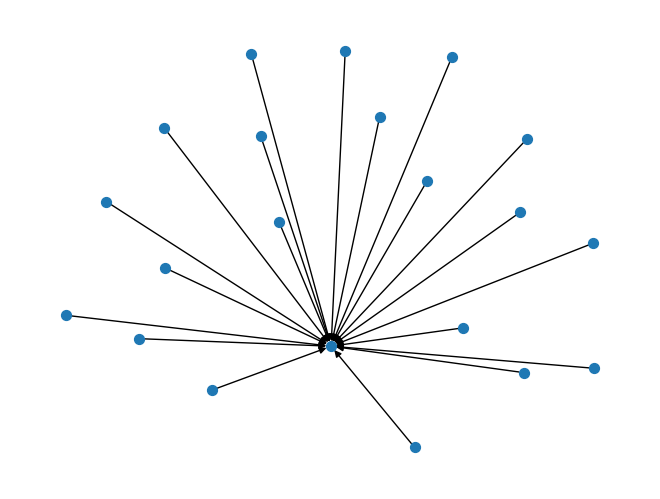

In [51]:
G_nx = nx.DiGraph()

for s, p, o in g:
    if isinstance(o, URIRef):
        G_nx.add_edge(str(s), str(o), label=str(p))

print("NetworkX nodes:", G_nx.number_of_nodes())
print("NetworkX edges:", G_nx.number_of_edges())

# Visualize small subgraph
sub_nodes = list(G_nx.nodes())[:50]
subgraph = G_nx.subgraph(sub_nodes)

plt.figure()
pos = nx.spring_layout(subgraph)
nx.draw(subgraph, pos, node_size=50, with_labels=False)
plt.show()

# =========================

# 12. Serialization

# =========================


In [52]:
# Save graph in different formats
g.serialize("output.ttl", format="turtle")
g.serialize("output.rdf", format="xml")

<Graph identifier=Ne509bd0cdd9a41acb2c08f1b9450a52c (<class 'rdflib.graph.Graph'>)>

# =========================

# 13. Advanced: Reasoning (basic)

# =========================


In [53]:
# Example: find all broader chains manually


def get_broader_chain(graph, node, depth=3):
    chain = []
    current = node
    for _ in range(depth):
        parent = list(graph.objects(current, SKOS.broader))
        if not parent:
            break
        current = parent[0]
        chain.append(current)
    return chain


sample = next(iter(subjects))
print("\nBroader chain:", get_broader_chain(g, sample))


Broader chain: []


# =========================

# 14. Statistics & Insights

# =========================



Top predicates:
predicate
https://permid.org/ontology/financial/currencySymbol    20
https://permid.org/ontology/financial/isoCode           20
https://permid.org/ontology/financial/isActive          20
http://www.w3.org/2000/01/rdf-schema#label              20
https://permid.org/ontology/financial/issuingCountry    20
http://www.w3.org/1999/02/22-rdf-syntax-ns#type         20
Name: count, dtype: int64


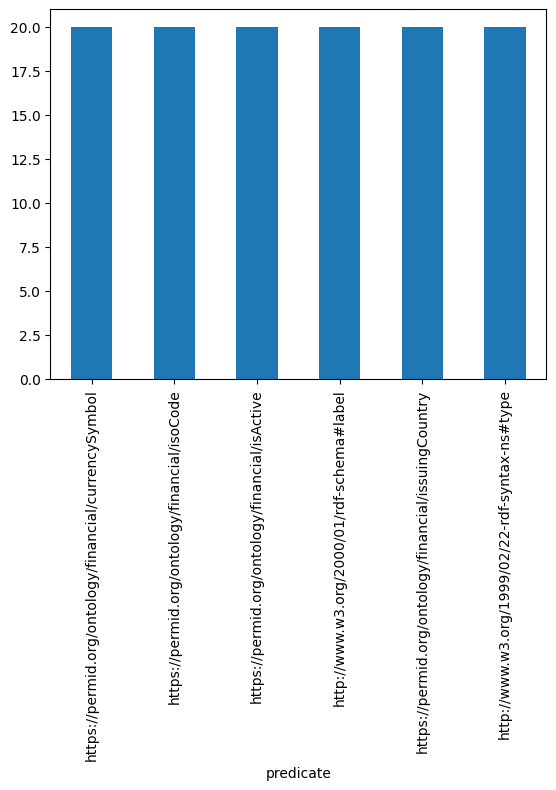

In [54]:
print("\nTop predicates:")
print(predicate_counts.head(30))

# Distribution plot
plt.figure()
predicate_counts.plot(kind="bar")
plt.show()

# =========================

# END

# =========================
